# Implement an End to End CNN Model for Image Classification Task.

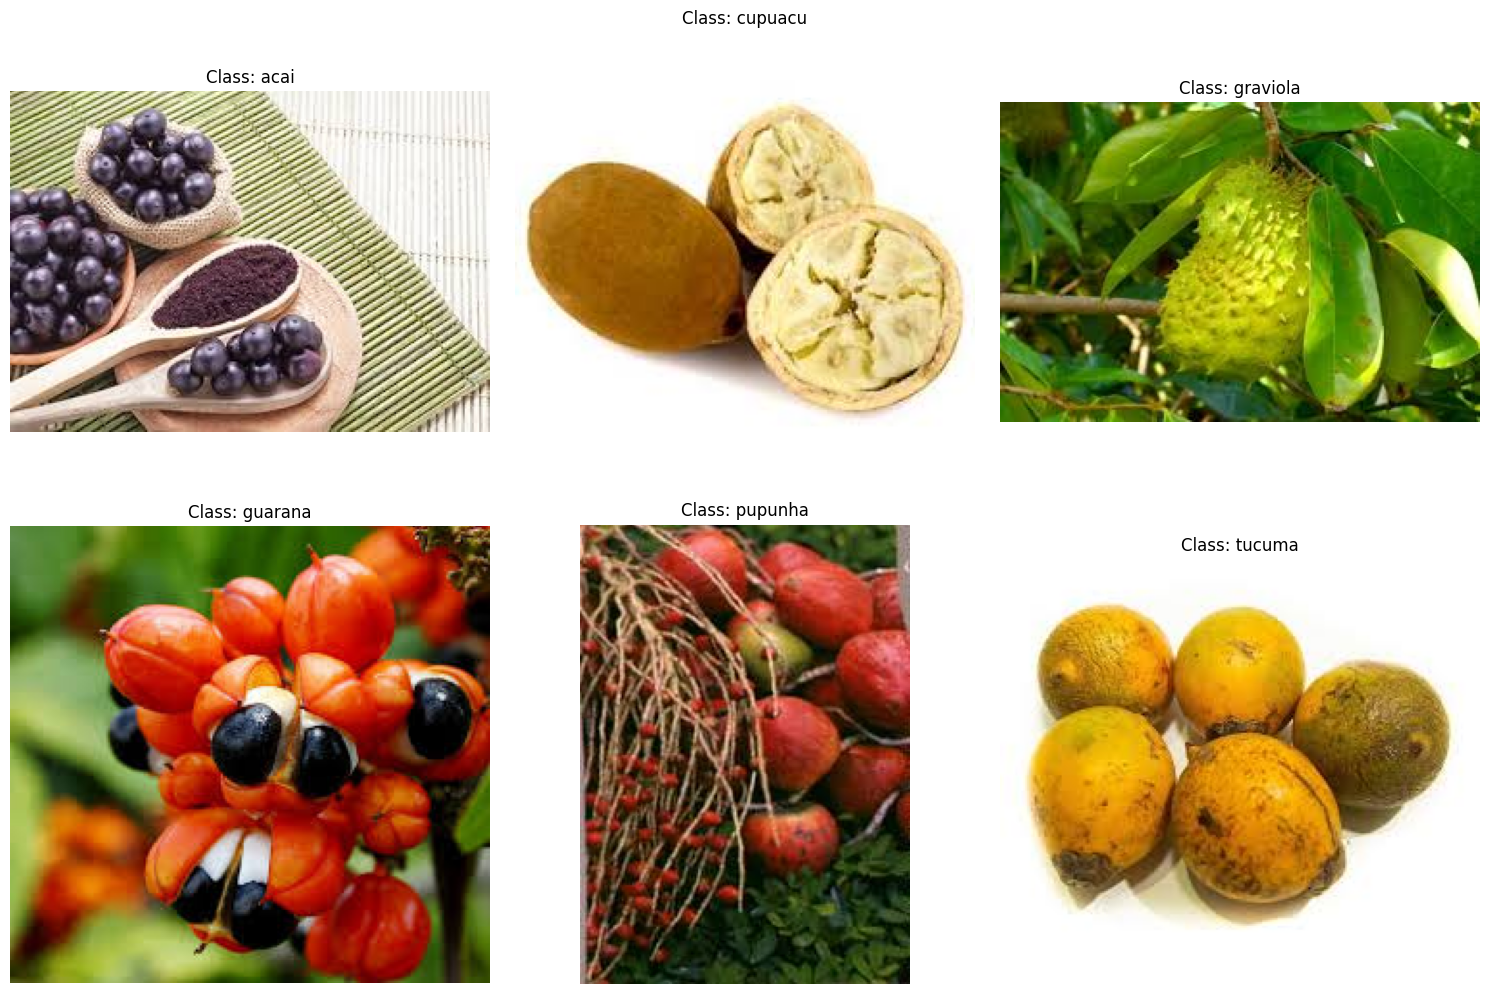

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.1806 - loss: 1.8902 - val_accuracy: 0.0556 - val_loss: 2.0221
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2083 - loss: 1.7754 - val_accuracy: 0.1111 - val_loss: 1.8842
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.3611 - loss: 1.5931 - val_accuracy: 0.2778 - val_loss: 1.7784
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.3889 - loss: 1.3723 - val_accuracy: 0.2222 - val_loss: 1.6365
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5694 - loss: 1.2436 - val_accuracy: 0.3333 - val_loss: 1.8552
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5556 - loss: 1.0747 - val_accuracy: 0.3333 - val_loss: 1.7896
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6667 - loss: 0.8990 - va

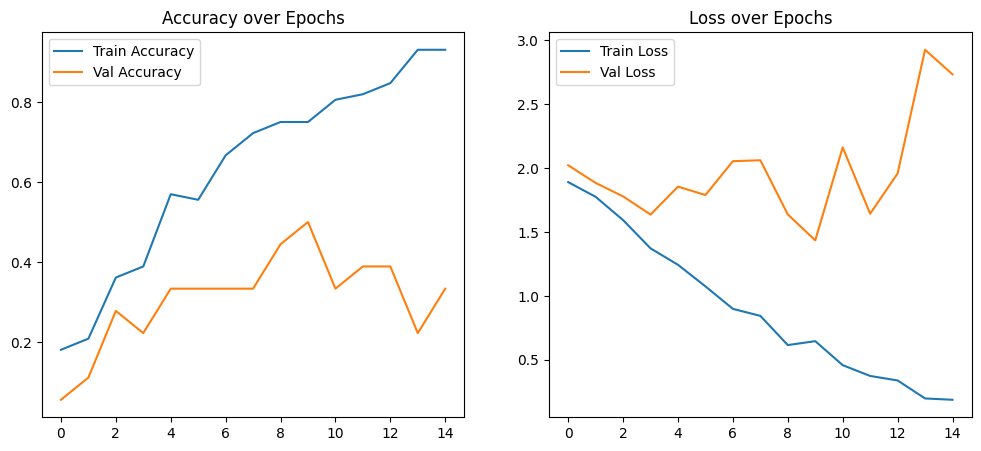

In [6]:
import zipfile
import os
import random
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 1. Extraction and Directory Setup
zip_path = '/content/FruitinAmazon.zip'
extract_path = '/content/fruit_dataset'
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

train_dir = os.path.join(extract_path, 'FruitinAmazon/train')
test_dir = os.path.join(extract_path, 'FruitinAmazon/test')

# Exercise: Data Inspection and Visualization
# • Get the list of class directories from the train folder.
classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

# • Select one image randomly from each class and display in a grid (two rows).
plt.figure(figsize=(15, 10))
for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)
    random_image = random.choice(images)
    img_path = os.path.join(class_path, random_image)

    img = mpimg.imread(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {class_name}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# 2. Data Loading & Preprocessing
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="training", seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="validation", seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 3. CNN Architecture
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Rescaling(1./255),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(len(classes), activation='softmax')
])

# 4. Compilation
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 5. Training
history = model.fit(train_ds, validation_data=val_ds, epochs=15)

# 6. Evaluation on Test Data
print("\nEvaluating on Test Dataset:")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

# 7. Visualization of Results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()